In [ ]:
# Cell 1
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

In [ ]:
# Cell 2
# Load the dataset

filename = 'full_dataset_cleaned_noCategory.csv'
folder = 'data'

csv_filep = os.path.join(os.getcwd(), folder, filename)

df = pd.read_csv(csv_filep)

# Quick check
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (300153, 38)


,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Bangalore,...,arrival_time_Morning,arrival_time_Night,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Business,class_Economy
0,2.17,1,5953,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,2.33,1,5953,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2.17,1,5956,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2.25,1,5955,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,2.33,1,5955,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [3]:
# Cell 3
# Create 3 bins for Low, Medium, High based on quantiles
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])
#separate them into 3 group by top,mid,lowest 33%

# Check the distribution
print("Class Distribution:")
print(df['price_category'].value_counts())

Class Distribution:
price_category
Low       100058
High      100048
Medium    100047
Name: count, dtype: int64


In [4]:
# Cell 4
# Randomly sample 200,000 rows ()
df_sample = df.sample(n=200000, random_state=42)

print("Sampled Dataset Shape:", df_sample.shape)

Sampled Dataset Shape: (200000, 39)


In [5]:
# Cell 5
# Define Features and Target
X = df_sample.drop(columns=['price', 'price_category'])
y = df_sample['price_category']

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Standardization)
scaler = StandardScaler()

# fit the scaler on the columns 'duration' and 'days_left'
cols_to_scale = ['duration', 'days_left']

# Scale training data
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Scale test data
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Convert to NumPy arrays for our class
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

print("Data scaled and converted to NumPy arrays.")

Data scaled and converted to NumPy arrays.


In [6]:
#cell 6
class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        # Gradient Descent
        for _ in range(self.n_iters):
            # Calculate: y * (w.x - b)
            linear_model = np.dot(X, self.w) - self.b

            # Condition: y_i * (w * x_i - b) < 1
            distances = y * linear_model
            violated_mask = distances < 1  
            
            # Gradient for w: 2*lambda*w - sum(y_i * x_i)
            dw = 2 * self.lambda_param * self.w
            db = 0
            
            #soft margine
            if np.any(violated_mask):
                # subtract the data term for violated samples
                violated_y = y[violated_mask]
                violated_X = X[violated_mask]
                
                dw -= np.dot(violated_y, violated_X)  #output of how much a point violate
                db -= np.sum(violated_y)  # Shit the line accordingly (bias)

            # Update weights
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def decision_function(self, X):
        return np.dot(X, self.w) - self.b
    # This single line complex flight data into a single numerical score with signed
    # for high model if +ve means high price, -ve means no high

class MultiClassSVM:
    def __init__(self, n_iters=1000, lr=0.001, lambda_param=0.01):
        self.n_iters = n_iters
        self.lr = lr
        self.lambda_param = lambda_param
        self.models = {}
        self.classes = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        print(f"Training One-vs-Rest SVMs for classes: {self.classes}")
        
        for c in self.classes:
            # Create binary target: 1 if class is c, -1 otherwise
            y_binary = np.where(y == c, 1, -1)
            
            model = LinearSVM(n_iters=self.n_iters, learning_rate=self.lr, lambda_param=self.lambda_param)
            model.fit(X, y_binary)
            self.models[c] = model
            print(f" - Model for class '{c}' trained.")

    def predict(self, X): # Get scores from all models
        scores = np.zeros((X.shape[0], len(self.classes)))
        
        for idx, c in enumerate(self.classes):
            scores[:, idx] = self.models[c].decision_function(X)
        
        # Pick the class with the highest score
        return self.classes[np.argmax(scores, axis=1)]
        #+ve score means the point is at correct side of the SVM

print("SVM classes defined.")

SVM classes defined.


In [7]:
#cell 7
# Initialize our model
svm_model = MultiClassSVM(n_iters=500, 
                          lr=0.0001, 
                          lambda_param=0.01)

print("Starting training...")
svm_model.fit(X_train_np, y_train_np)
print("Training complete!")

Starting training...
Training One-vs-Rest SVMs for classes: ['High' 'Low' 'Medium']
 - Model for class 'High' trained.
 - Model for class 'Low' trained.
 - Model for class 'Medium' trained.
Training complete!


In [8]:
#cell 8
# Predict on the test set
y_pred = svm_model.predict(X_test_np)

# Calculate Accuracy
accuracy = accuracy_score(y_test_np, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred))

Model Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.93      0.97     13260
         Low       0.76      0.74      0.75     13426
      Medium       0.70      0.76      0.73     13314

    accuracy                           0.81     40000
   macro avg       0.82      0.81      0.81     40000
weighted avg       0.82      0.81      0.81     40000



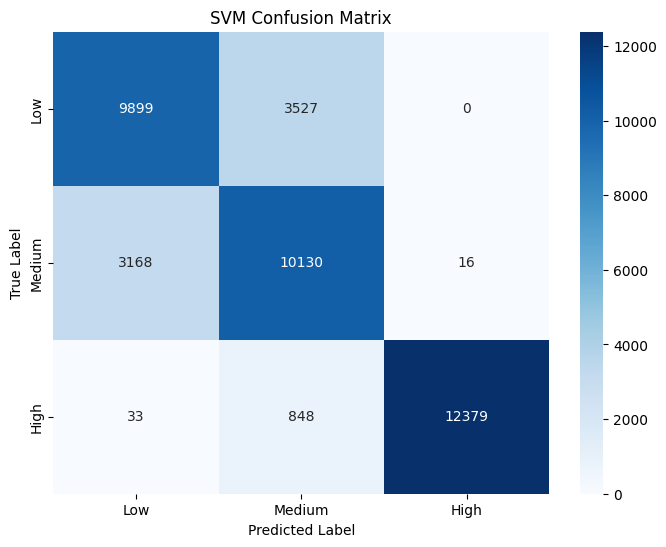

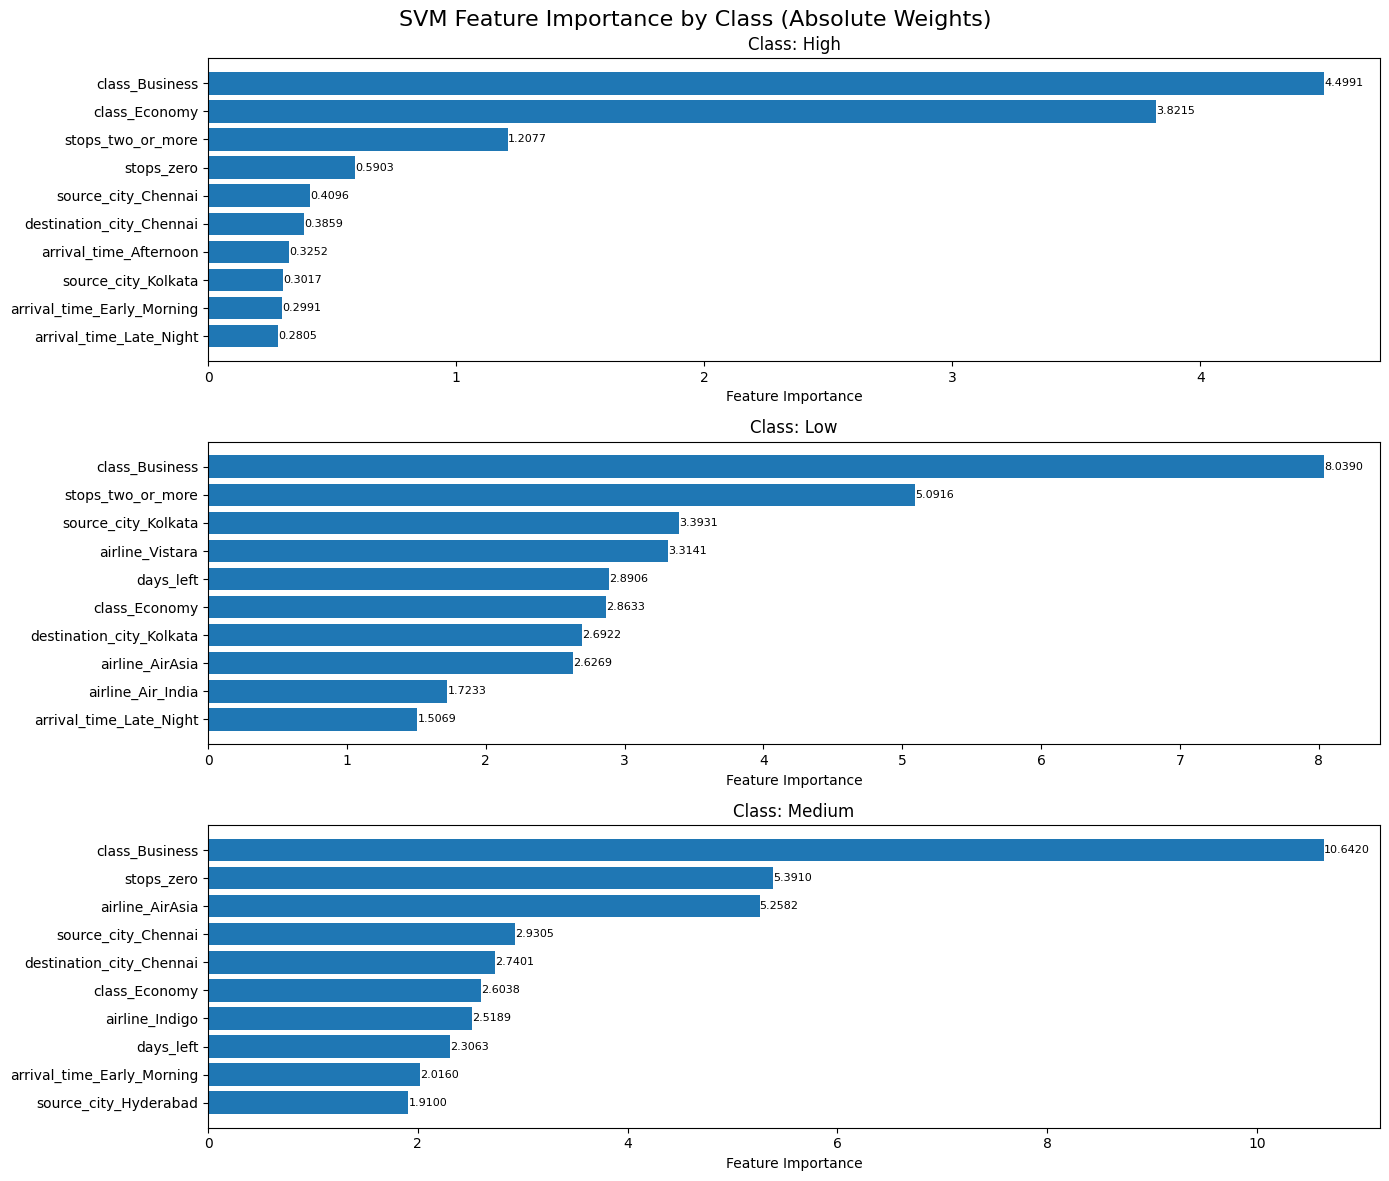

In [9]:
#cell 9
# Plot Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Get feature importance from the SVM models
# Plot feature importance for each class separately
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('SVM Feature Importance by Class (Absolute Weights)', fontsize=16)

for idx, (class_name, model) in enumerate(svm_model.models.items()):
    # Get absolute weights for this class
    importance = np.abs(model.w)
    
    # Create DataFrame
    class_importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': importance
    })
    
    # Sort by importance
    class_importance_df = class_importance_df.sort_values('importance', ascending=True)
    
    # Plot top 10 features
    top_n = min(10, len(class_importance_df))
    top_features = class_importance_df.tail(top_n)
    
    ax = axes[idx]
    bars = ax.barh(range(len(top_features)), top_features['importance'])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Class: {class_name}')
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, top_features['importance'])):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{value:.4f}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()



In [10]:
#cell 10
# Get Predictions on Training Data 
y_train_pred = svm_model.predict(X_train_np)

# Calculate accuracy
train_acc = accuracy_score(y_train_np, y_train_pred)
test_acc = accuracy_score(y_test_np, y_pred)

# 3. Print Comparison
print(f"\n--- Overfitting Check ---")
print(f"Training Accuracy: {train_acc:.4%}")
print(f"Testing Accuracy:  {test_acc:.4%}")

gap = train_acc - test_acc
print(f"Gap: {gap:.2%} points")


--- Overfitting Check ---
Training Accuracy: 81.0100%
Testing Accuracy:  81.0200%
Gap: -0.01% points


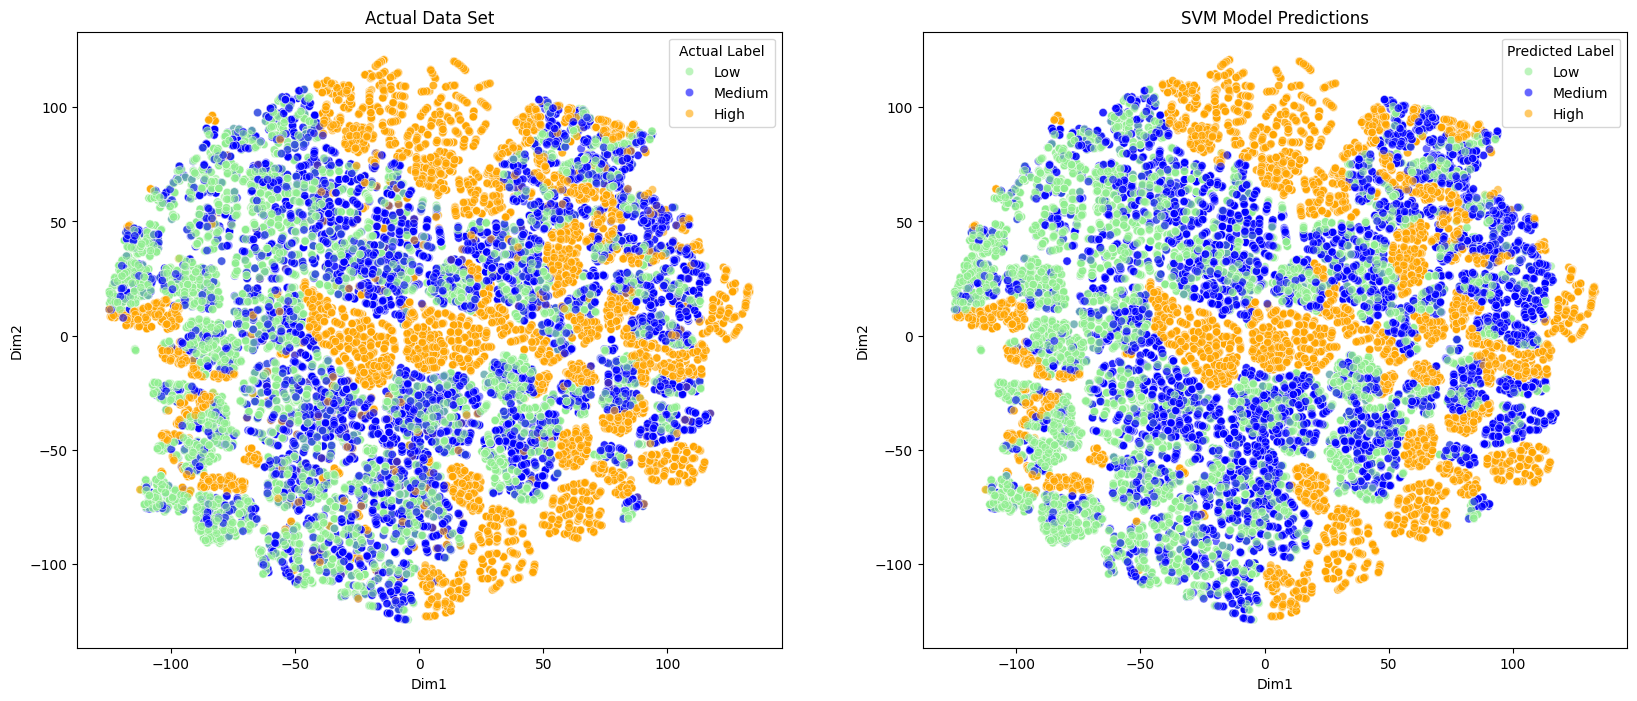

In [11]:
#cell 11
#t-SNE Visualization

# Choosing Colors for class
color = {
    'Low': 'lightgreen',
    'Medium': 'blue',
    'High': 'orange'
}

#Run t-SNE on the Test Set
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_test_tsne = tsne.fit_transform(X_test)

# Prepare Data for Plotting
tsne_df = pd.DataFrame(data=X_test_tsne, columns=['Dim1', 'Dim2'])
tsne_df['Actual Label'] = y_test.values
tsne_df['Predicted Label'] = y_pred

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot A: The actual class
sns.scatterplot(
    data=tsne_df, 
    x='Dim1', 
    y='Dim2', 
    hue='Actual Label', 
    palette=color,                          #  custom colors
    hue_order=['Low', 'Medium', 'High'],    # Force legend order
    alpha=0.6,                              #transparency
    ax=axes[0]                              #plot at left side
)
axes[0].set_title("Actual Data Set")

# Plot B: The SVM Prediction
sns.scatterplot(
    data=tsne_df, 
    x='Dim1', 
    y='Dim2', 
    hue='Predicted Label', 
    palette=color,  
    hue_order=['Low', 'Medium', 'High'], 
    alpha=0.6, 
    ax=axes[1]
)
axes[1].set_title("SVM Model Predictions")

plt.show()